# Multi-Chart Visualization Notebook

This notebook uses the Titanic dataset to compare survival, fare, age, class, and family patterns across six chart types.

In [24]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, Markdown

In [18]:
# Load the Titanic dataset.
df = pd.read_csv(r"c:\Users\PM\Desktop\Internship\AI-Data-Engineering-Internship\Week-6 May_26\Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
# Make a copy so the original data stays unchanged.
plot_df = df.copy()

plot_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
# Convert the columns we will use in charts into numeric values.
plot_df["Age"] = pd.to_numeric(plot_df["Age"], errors="coerce")
plot_df["Fare"] = pd.to_numeric(plot_df["Fare"], errors="coerce")

plot_df[["Age", "Fare"]].head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [21]:
# Group ages into simple bands for the line chart.
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
plot_df["AgeBand"] = pd.cut(plot_df["Age"], bins=age_bins, right=False)
plot_df["AgeBandLabel"] = plot_df["AgeBand"].astype(str)

plot_df[["Age", "AgeBand", "AgeBandLabel"]].head()

,Age,AgeBand,AgeBandLabel
0,22.0,"[20, 30)","[20.0, 30.0)"
1,38.0,"[30, 40)","[30.0, 40.0)"
2,26.0,"[20, 30)","[20.0, 30.0)"
3,35.0,"[30, 40)","[30.0, 40.0)"
4,35.0,"[30, 40)","[30.0, 40.0)"


In [27]:
# Convert each age band into a number we can plot on the x-axis.
def get_age_band_center(age_band):
    if pd.isna(age_band):
        return None
    return age_band.left + 5

plot_df["AgeBandCenter"] = plot_df["AgeBand"].apply(get_age_band_center)
plot_df["SurvivedLabel"] = plot_df["Survived"].map({0: "Did not survive", 1: "Survived"})

plot_df[["AgeBandCenter", "SurvivedLabel"]].head()

,AgeBandCenter,SurvivedLabel
0,25.0,Did not survive
1,35.0,Survived
2,25.0,Survived
3,35.0,Survived
4,35.0,Did not survive


In [25]:
# Set a clean theme for all charts.
sns.set_theme(style="whitegrid")

# Create a folder for Task 1 image outputs.
task1_output_folder = r"c:\Users\PM\Desktop\Internship\AI-Data-Engineering-Internship\Week-6 May_26\Task1"
os.makedirs(task1_output_folder, exist_ok=True)
task1_output_folder

'c:\\Users\\PM\\Desktop\\Internship\\AI-Data-Engineering-Internship\\Week-6 May_26\\Task1'

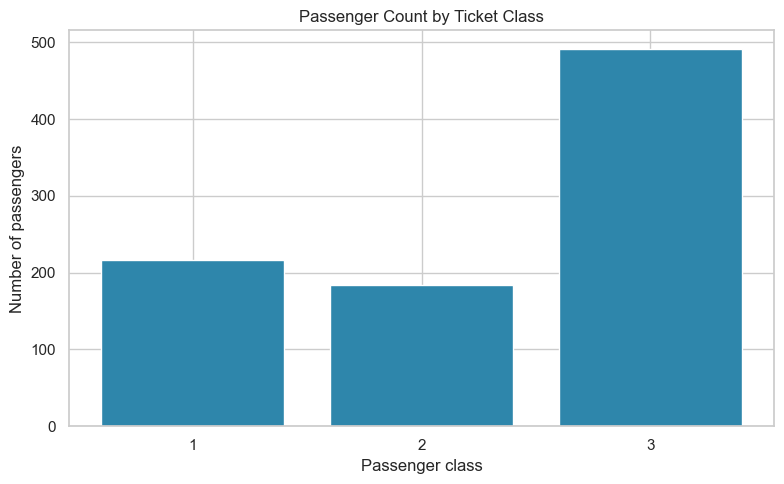

Insight: Third-class passengers made up the largest group, showing the ship carried far more economy travelers than higher-class passengers.

In [26]:
# Bar chart: passenger count by class
# Count how many passengers were in each class.
class_counts = plot_df["Pclass"].value_counts().sort_index()
class_labels = class_counts.index.astype(str)
class_values = class_counts.values

plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_values, color="#2E86AB")
plt.title("Passenger Count by Ticket Class")
plt.xlabel("Passenger class")
plt.ylabel("Number of passengers")
plt.tight_layout()
plt.savefig(os.path.join(task1_output_folder, "task1_bar_chart.png"), dpi=300, bbox_inches="tight")
plt.show()

display(Markdown("Insight: Third-class passengers made up the largest group, showing the ship carried far more economy travelers than higher-class passengers."))

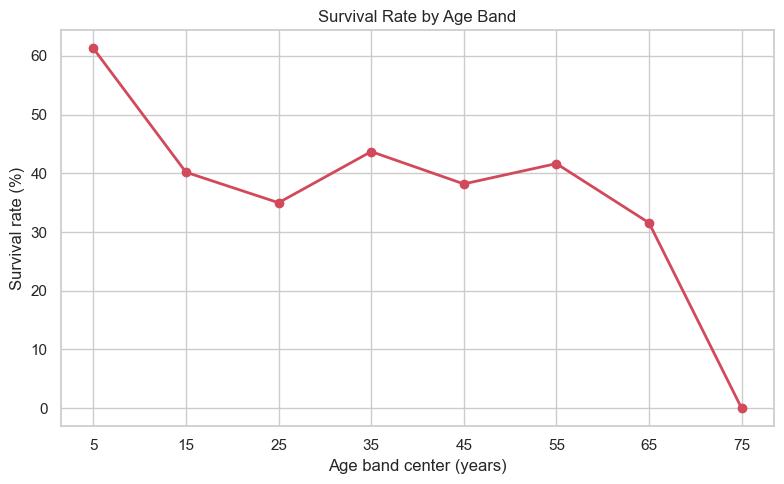

Insight: Survival tended to be higher among children and younger passengers, then generally softened in older age bands.

In [28]:
# Line chart: survival rate by age band
# Find the average survival rate for each age band.
age_grouped = plot_df.groupby("AgeBandCenter", dropna=True)
age_survival = age_grouped["Survived"].mean().dropna()
age_survival = age_survival * 100

age_x = age_survival.index
age_y = age_survival.values
age_x_labels = [str(int(value)) for value in age_x]

plt.figure(figsize=(8, 5))
plt.plot(age_x, age_y, marker="o", linewidth=2, color="#D1495B")
plt.title("Survival Rate by Age Band")
plt.xlabel("Age band center (years)")
plt.ylabel("Survival rate (%)")
plt.xticks(age_x, age_x_labels)
plt.tight_layout()
plt.savefig(os.path.join(task1_output_folder, "task1_line_chart.png"), dpi=300, bbox_inches="tight")
plt.show()

display(Markdown("Insight: Survival tended to be higher among children and younger passengers, then generally softened in older age bands."))

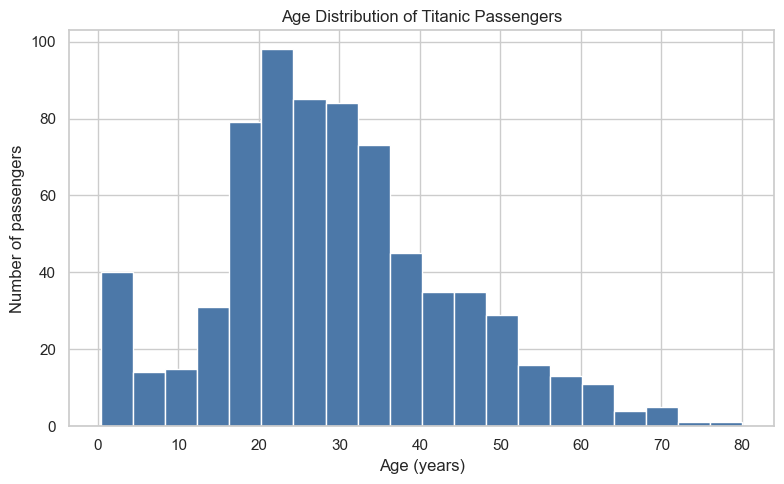

Insight: The passenger ages cluster heavily in the young adult range, with far fewer very young children and elderly passengers.

In [29]:
# Histogram: age distribution
# Drop missing ages before plotting.
age_values = plot_df["Age"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(age_values, bins=20, color="#4C78A8", edgecolor="white")
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age (years)")
plt.ylabel("Number of passengers")
plt.tight_layout()
plt.savefig(os.path.join(task1_output_folder, "task1_histogram.png"), dpi=300, bbox_inches="tight")
plt.show()

display(Markdown("Insight: The passenger ages cluster heavily in the young adult range, with far fewer very young children and elderly passengers."))

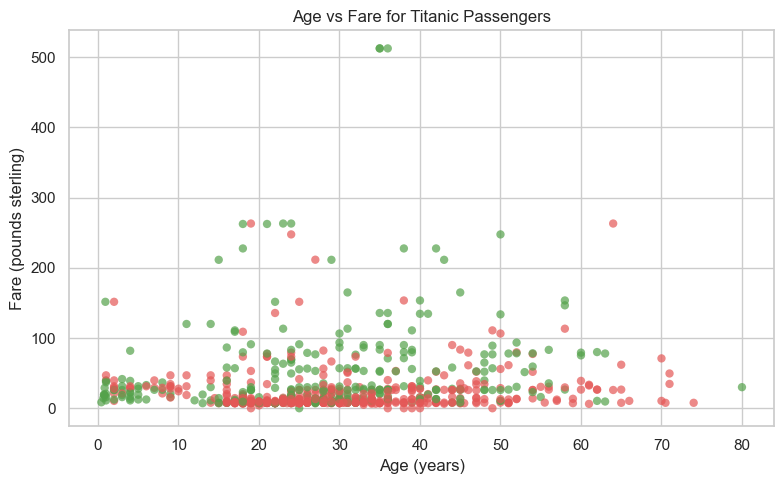

Insight: Higher fares are concentrated among a small number of passengers, while most passengers paid relatively modest amounts regardless of age.

In [30]:
# Scatter plot: age vs fare
# Keep only rows that have both age and fare values.
scatter_df = plot_df.dropna(subset=["Age", "Fare"])

# Use different colors for passengers who survived and those who did not.
scatter_colors = []
for survived_value in scatter_df["Survived"]:
    if survived_value == 1:
        scatter_colors.append("#54A24B")
    else:
        scatter_colors.append("#E45756")

scatter_age = scatter_df["Age"]
scatter_fare = scatter_df["Fare"]

plt.figure(figsize=(8, 5))
plt.scatter(scatter_age, scatter_fare, c=scatter_colors, alpha=0.7, edgecolors="none")
plt.title("Age vs Fare for Titanic Passengers")
plt.xlabel("Age (years)")
plt.ylabel("Fare (pounds sterling)")
plt.tight_layout()
plt.savefig(os.path.join(task1_output_folder, "task1_scatter.png"), dpi=300, bbox_inches="tight")
plt.show()

display(Markdown("Insight: Higher fares are concentrated among a small number of passengers, while most passengers paid relatively modest amounts regardless of age."))

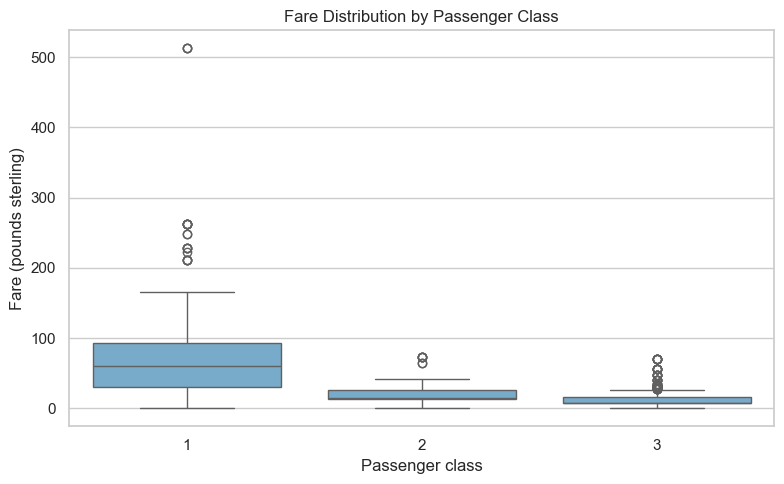

Insight: First-class passengers paid substantially higher fares, and the spread is widest in the top class because of a few very expensive tickets.

In [ ]:
# Box plot: fare by passenger class
# Keep only the columns we need and remove missing values.
fare_box_df = plot_df[["Pclass", "Fare"]].dropna()

plt.figure(figsize=(8, 5))
sns.boxplot(data=fare_box_df, x="Pclass", y="Fare", hue="Pclass", palette="Set2", dodge=False, legend=False)
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger class")
plt.ylabel("Fare (pounds sterling)")
plt.tight_layout()
plt.savefig(os.path.join(task1_output_folder, "task1_box_plot.png"), dpi=300, bbox_inches="tight")
plt.show()

display(Markdown("Insight: First-class passengers paid substantially higher fares, and the spread is widest in the top class because of a few very expensive tickets."))

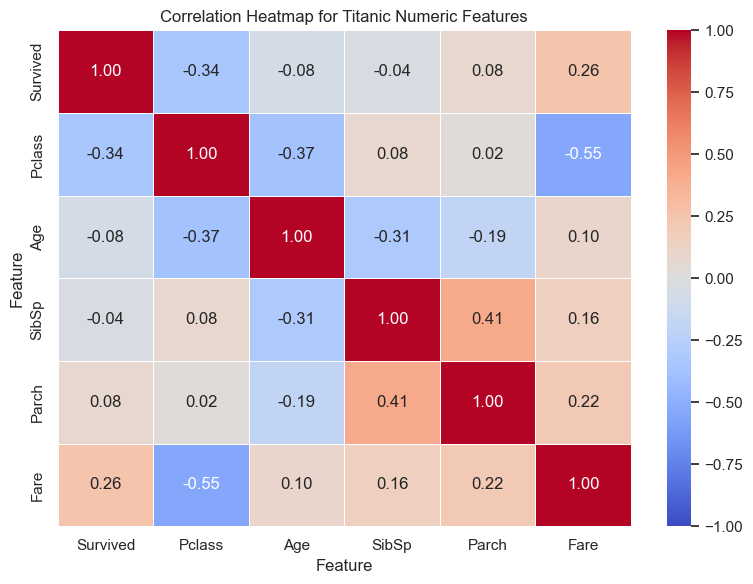

Insight: Passenger class and fare show the strongest inverse relationship, while survival is only moderately associated with class and fare.

In [ ]:
# Heatmap: correlations among numeric variables
# Select the numeric columns we want to compare.
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
numeric_data = plot_df[numeric_cols]
correlation_matrix = numeric_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Correlation Heatmap for Titanic Numeric Features")
plt.xlabel("Feature")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(task1_output_folder, "task1_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

display(Markdown("Insight: Passenger class and fare show the strongest inverse relationship, while survival is only moderately associated with class and fare."))